# CAB320 Assignment 2 - Transfer Learning
Anthony Vanderkop, Thierry Peynot, Frederic Maire (Jupyter Notebook template: 2025)


Anthony Vanderkop, Thierry Peynot, Frederic Maire (Jupyter Notebook template: 2025)

## Instructions:
The functions and classes defined in this module will be called by the marker without modification. You should complete the functions and classes according to their specified interfaces.

No partial marks will be awarded for functions that do not meet the specifications of the interfaces.

In [5]:
### LIBRARY IMPORTS ###
import os
import numpy as np

import keras.applications as ka
import keras
import pandas as pd
import matplotlib.pyplot as plt
import os
import cv2
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_recall_fscore_support
import tensorflow as tf

## Task 1
Implement the my_team()function 

In [6]:
def my_team():
    '''
    Return the list of the team members of this assignment submission as a list
    of triplet of the form (student_number, first_name, last_name)
    
    '''
    return [('n0827053', 'Ashley', 'Longhurst'), ('n9439960','Kyle', 'Ruter'), ('n12393631', 'Katherine', 'Newman')] 

In [7]:
my_team()

[('n0827053', 'Ashley', 'Longhurst'),
 ('n9439960', 'Kyle', 'Ruter'),
 ('n12393631', 'Katherine', 'Newman')]

## Task 2
Download the small_flower_dataset from Canvas and load the data

In [8]:
def load_data(path):
    '''
    Load in the dataset from its home path. Path should be a string of the path
    to the home directory the dataset is found in. Should return a numpy array
    with paired images and class labels.
    
    Loads images from subdirectories of the given path, resizes each to 128x128,
    converts from BGR to RGB, and encodes the class label as an integer using label_map.
    Returns a numpy array of (image, label) pairs.
    '''
    subfolders = ['daisy', 'dandelion', 'roses', 'tulips', 'sunflowers']
    
    images = []
    labels = []
    
    label_map = {
        'daisy': 0,
        'dandelion': 1,
        'roses': 2,
        'tulips': 3,
        'sunflowers': 4
    }

    # Load the images
    for subfolder in subfolders:
        full_path = os.path.join(path, subfolder)   # uses the argument now
        image_files = os.listdir(full_path)
    
        for img_file in image_files:
            img_path = os.path.join(full_path, img_file)
            img = cv2.imread(img_path)
    
            if img is not None:
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                img = cv2.resize(img, (128, 128))
                images.append(img)
                labels.append(label_map[subfolder])
    
    X = np.array(images)
    y = np.array(labels)
    
    print("All images shape:", X.shape)
    print("All labels shape:", y.shape)
    print("Class labels:", label_map)
    dataset = np.array(list(zip(X, y)), dtype=object)
    return dataset

In [9]:
dataset = load_data('./small_flower_dataset')
X = np.array([item[0] for item in dataset])
Y = np.array([item[1] for item in dataset])

All images shape: (1000, 128, 128, 3)
All labels shape: (1000,)
Class labels: {'daisy': 0, 'dandelion': 1, 'roses': 2, 'tulips': 3, 'sunflowers': 4}


In [10]:
"""
We want to have a look at how the images are set up
"""

print((X[0][0][:5])) # The first row of pixels just to look at the values 0 - 255. Each pixel RGB values
print(len(X[0][0])) # 128 - First row has 128. So all looks ok. 

[[146 145 128]
 [166 165 141]
 [ 86  89  56]
 [136 132 104]
 [123 122  91]]
128


In [11]:
"""
A quick check to see how the data is structured and to see if
class labels a fairly balanced. This code block wont be imcluded in the final submission.
"""
print(np.unique(Y, return_counts=True)) # We can see there are 200 of each

(array([0, 1, 2, 3, 4]), array([200, 200, 200, 200, 200]))


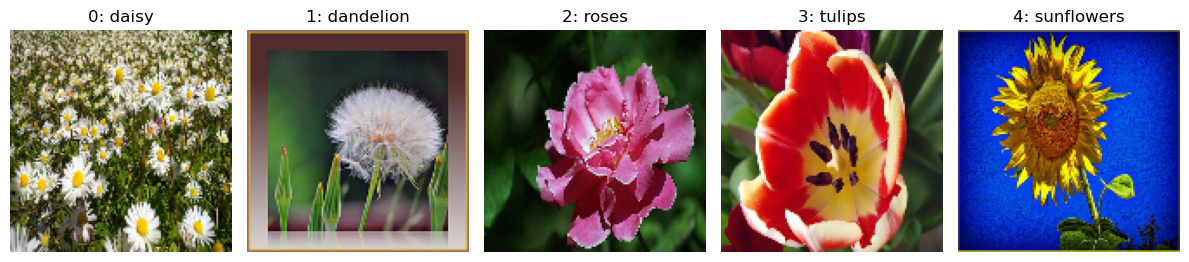

In [12]:
"""
This code block is just to see the load has worked
and to see if the labels and the images are matched.
It probably wont be included in the final submission
"""

label_map_check = {
    0: 'daisy',
    1: 'dandelion',
    2: 'roses',
    3: 'tulips',
    4: 'sunflowers'
}

plt.figure(figsize=(12, 4))

for flower_label in range(5):
    for i in range(len(dataset)):
        image = dataset[i][0]
        label = dataset[i][1]

        if label == flower_label:
            plt.subplot(1, 5, flower_label + 1)
            plt.imshow(image)
            plt.title(f"{label}: {label_map_check[label]}")
            plt.axis('off')
            break

plt.tight_layout()
plt.show()

## Task 3
Prepare your training, validation and test sets for the non-accelerated version of transfer learning.

In [13]:
def split_data(X, Y, train_fraction, randomize=False, eval_set=True):
    """
    Split the data into training and testing sets. If eval_set is True, also create
    an evaluation dataset. There should be two outputs if eval_set there should
    be three outputs (train, test, eval), otherwise two outputs (train, test).
    
    To see what type train, test, and eval should be, refer to the inputs of 
    transfer_learning().
    
    This uses sklearn's train test split library. See https://scikit-learn.org/stable/modules/generated/
    sklearn.model_selection.train_test_split.html. The output type conforms to the transfer_learning()
    input data type (a tuple of images and labels : eg (images, labesl)). Random state is utilised for reproducability
    initially among team members and the randomise is used to ensure no class imbalance.
    """
    if eval_set:
        # First split: training set and leftover set
        X_train, X_temp, Y_train, Y_temp = train_test_split(
            X,
            Y,
            train_size=train_fraction,
            shuffle=True,
            stratify=Y,
            random_state=42
        )

        # Second split: split leftover data equally into test and eval sets
        X_test, X_eval, Y_test, Y_eval = train_test_split(
            X_temp,
            Y_temp,
            test_size=0.5,
            shuffle=True,
            stratify=Y_temp,
            random_state=42
        )

        train = (X_train, Y_train)
        test = (X_test, Y_test)
        eval_data = (X_eval, Y_eval)

        return train, test, eval_data

    else:
        X_train, X_test, Y_train, Y_test = train_test_split(
            X,
            Y,
            train_size=train_fraction,
            shuffle=True,
            stratify=Y,
            random_state=42
        )

        train = (X_train, Y_train)
        test = (X_test, Y_test)

        return train, test

In [14]:
def get_sets(X, Y, train_ratio=0.8, randomize=True, use_eval=True):
    '''
    Split data into train/test sets, with an optional evaluation set.
    '''
    if use_eval:
        train_set, test_set, eval_set = split_data(
            X, Y, train_ratio, randomize=randomize, eval_set=True
        )
    else:
        train_set, test_set = split_data(
            X, Y, train_ratio, randomize=randomize, eval_set=False
        )
        eval_set = None
    return train_set, test_set, eval_set

In [15]:
train_set, test_set, eval_set = get_sets(X, Y, train_ratio=0.8, randomize=True, use_eval=True)

In [16]:
"""
Plots to show how the train test split function worked 
and if any class imbalance exists in the sets. This can be talked
about in the text block below later on. 
"""
def plot_class_distributions(train_set, test_set, eval_set=None, label_map=None):
 
    sets = [('Training Set', train_set[1]), ('Testing Set', test_set[1])]
    if eval_set is not None:
        sets.append(('Evaluation Set', eval_set[1]))

    n = len(sets)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 4))

    if n == 1:
        axes = [axes]

    for ax, (title, y) in zip(axes, sets):
        unique, counts = np.unique(y, return_counts=True)
        names = [label_map[i] for i in unique] if label_map else unique
        ax.bar(names, counts)
        ax.set_title(f'{title} (n={len(y)})')
        ax.set_ylabel('Count')
        ax.tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

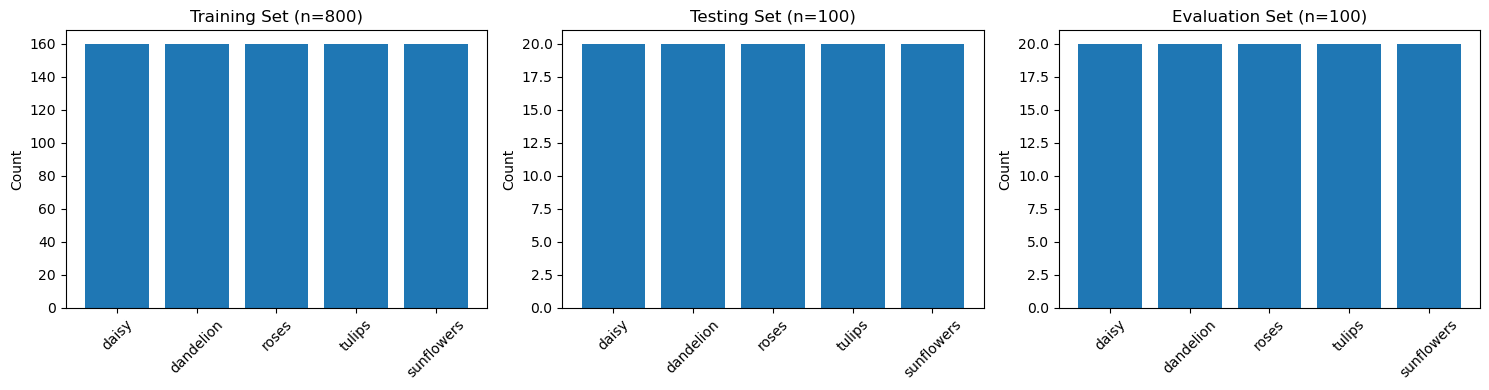

In [17]:
plot_class_distributions(train_set, test_set, eval_set, label_map=label_map_check)

### Report:
**Include details of how you have split the data to perform this training. Ensure the split is reasonable and does not introduce class imbalance during training**

The dataset was divided into training, testing, and evaluation sets using a two step process with scikit-learn's train test split function. 80% of the data was allocated to the training set, with the remaining 20% further divided into a 10% test set and a 10% evaluation set. Stratification was applied at both stages to ensure the proportional representation of each class is preserved across all splits to avoid class imbalance. A fixed random state was used throughout for reproducibility across team members. Because the training set is large (n=800), the class counts remain even when stratified. The test and evaluation sets (n=100 each) contain 20 samples per class, ensuring even class representation. The above plots show no class imbalance.

## Task 4
Using the tf.keras.applications module download a pretrained MobileNetV2 network. 

In [27]:
def load_model():
    '''
    Load in a model using the tf.keras.applications model and return it.
    Downloads and returns a pretrained MobileNetV2 model with ImageNet weights
    and the default top (classification) layer included. Input shape defaults to (224, 224, 3).
    '''
    model = tf.keras.applications.MobileNetV2(
    weights='imagenet'
    )

    return model    

In [28]:
model = load_model()
model.summary()

Model: "mobilenetv2_1.00_224"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_3[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 3,538,984 (13.50 MB)

 Trainable params: 3,504,872 (13.37 MB)

 Non-trainable params: 34,112 (133.25 KB)

(224, 224, 3)


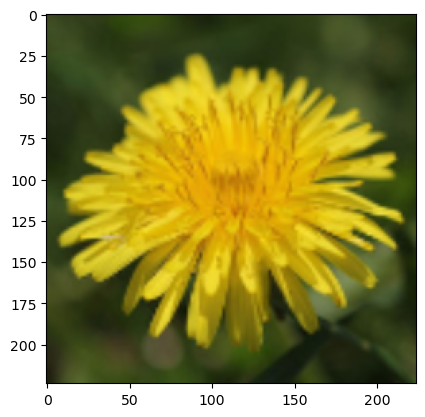

In [29]:
"""
Having a look at the pretrained model, we can see that the input layer is 224x224x3.
Our images are 128x128x3. As the model is pretrained on 224 images we shouldn't change the weights in the
actual model. We need to resize our own images to conform to the input size of the pretrained model. Also, have to
try and find what sort of data the MobileNetV2 was trained on. eg was it (0-255) or something different.
It was (-1 : +1). Quote from Keras page " Note: each TF-Keras Application expects a specific 
kind of input preprocessing. For MobileNet, call tf.keras.applications.mobilenet.preprocess_input on 
your inputs before passing them to the model. mobilenet.preprocess_input will scale input pixels between -1 and 1."
"""

# Resize all sets of images (Train, Test, Val)

resized_train = tf.image.resize(train_set[0], [224, 224])
resized_test = tf.image.resize(test_set[0], [224, 224])
resized_val = tf.image.resize(eval_set[0], [224, 224])

# Check to see if it worked
print(resized_train[0].shape)

# What does it look like
plt.imshow(resized_train[0] / 255.0)

# Rescale images
final_train_imgs = tf.keras.applications.mobilenet_v2.preprocess_input(resized_train)
final_test_imgs = tf.keras.applications.mobilenet_v2.preprocess_input(resized_test)
final_val_imgs = tf.keras.applications.mobilenet_v2.preprocess_input(resized_val)

# Add the labels back
final_train = (final_train_imgs, train_set[1])
final_test  = (final_test_imgs,  test_set[1])
final_val   = (final_val_imgs,   eval_set[1])

## Task 5
Replace the last layer of the downloaded neural network with a Dense layer of the appropriate shape for the 5 classes of the small flower dataset {(x1,t1), (x2,t2),..., (xm,tm)}.

In [30]:
def create_fresh_model():
    # Load a fresh MobileNetV2 n
    base = load_model()

    # Get the output of the previous layer (Global Average Pooling)
    previous_output = base.layers[-2].output

    # Add required final layer
    final_output = tf.keras.layers.Dense(5, activation='softmax')(previous_output)

    # Create the new model
    model = tf.keras.Model(inputs=base.input, outputs=final_output)

    # Freeze training on the original layers
    for layer in model.layers[:-1]:
        layer.trainable = False

    return model

In [31]:
new_model = create_fresh_model()
new_model.summary()

# From the last line of the summary we can see that only the last layer is trainable (6405).

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_4[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,264,389 (8.64 MB)

 Trainable params: 6,405 (25.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## Task 6
Compile and train your model with an SGD optimizer using the following parameters learning_rate=0.01, momentum=0.0, nesterov=False. (NB: The SGD class description can be found at https://keras.io/api/optimizers/sgd/  )

In [37]:
def transfer_learning(train_set, eval_set, model,epoch, parameters):
    '''
    Implement and perform standard transfer learning here.

    Inputs:
        - train_set: list or tuple of the training images and labels in the
            form (images, labels) for training the classifier
        - eval_set: list or tuple of the images and labels used in evaluating
            the model during training, in the form (images, labels)
        - model: an instance of tf.keras.applications.MobileNetV2
        - parameters: list or tuple of parameters to use during training:
            (learning_rate, momentum, nesterov)


    Outputs:
        - model : an instance of tf.keras.applications.MobileNetV2

    '''
    # Unpack the images and labels
    train_images, train_labels = final_train
    eval_images, eval_labels = final_val
    learning_rate, momentum, nesterov = parameters

    # Set up the optimiser
    optimizer = tf.keras.optimizers.SGD(
        learning_rate=learning_rate,
        momentum=momentum,
        nesterov=nesterov
    )

    # Compile the model
    model.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    # Train the model
    history = model.fit(
        train_images,
        train_labels,
        validation_data=(eval_images, eval_labels),
        epochs=epoch,
        batch_size=32,
        verbose=1
    )

    return model, history

In [33]:
parameters = (0.01, 0.0, False)
epoch = 20

model, history = transfer_learning(final_train, final_val, new_model,epoch, parameters)

Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 159ms/step - accuracy: 0.4588 - loss: 1.3585 - val_accuracy: 0.7400 - val_loss: 0.8085
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 127ms/step - accuracy: 0.7325 - loss: 0.8215 - val_accuracy: 0.8700 - val_loss: 0.5626
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 126ms/step - accuracy: 0.8050 - loss: 0.6414 - val_accuracy: 0.8700 - val_loss: 0.4772
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 126ms/step - accuracy: 0.8375 - loss: 0.5465 - val_accuracy: 0.8600 - val_loss: 0.4242
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 124ms/step - accuracy: 0.8487 - loss: 0.4906 - val_accuracy: 0.8900 - val_loss: 0.4014
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 124ms/step - accuracy: 0.8625 - loss: 0.4448 - val_accuracy: 0.8700 - val_loss: 0.3757
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 125ms/step - accuracy: 0.8763 - loss: 0.4100 - val_accuracy: 0.9100 - val_loss: 0.3507
Epoch 8/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 124ms/step - accuracy: 0.8900 - loss: 0.3805 - val_accuracy: 0.

### Report: 
**Provide an	overview of	the	function and how it works.**

The transfer_learning function compiles and trains a pre-built MobileNetV2 model. The function accepts the training and evaluation sets of images and labels, a model instance, number of epochs, and a parameters containing optimiser settings. The model uses sparse categorical cross-entropy as the loss function as class labels are provided as integers. Training is run over 20 epochs with a batch size of 32, with the evaluation set passed as validation data. The function returns the trained model and the history.
In this task, the function was called with an SGD optimiser configured with a learning rate of 0.01, momentum of 0.0, and Nesterov acceleration not used. 

## Task 7
Plot the training and validation errors and accuracies of standard transfer 

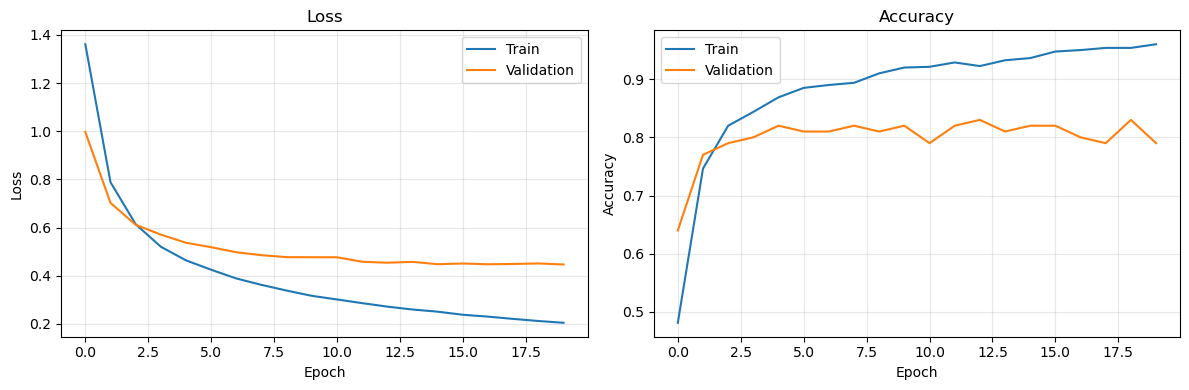

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['loss'], label='Train')
axes[0].plot(history.history['val_loss'], label='Validation')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['accuracy'], label='Train')
axes[1].plot(history.history['val_accuracy'], label='Validation')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Report:	Briefly	comment	on	the	results 

The loss and accuracy curves indicate that the model learned effectively over the 20 epochs. Training loss dropped sharply before continuing to decrease steadily. Validation loss followed a similar initial decline but plateaued around epoch 5, showing little further meaningful improvement. Training accuracy climbed consistently to approximately 95%, while validation accuracy stabilised at approximately 82–83%. The widening gap between training and validation loss and accuracy possibly indicates mild overfitting. 

## Task 8
Experiment with 3 different orders of magnitude for the learning rate. Plot the results and discuss in the below markdown cell


--- Training with learning_rate = 0.1 ---
Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 203ms/step - accuracy: 0.5375 - loss: 2.8155 - val_accuracy: 0.8300 - val_loss: 0.5721
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 124ms/step - accuracy: 0.8100 - loss: 0.7219 - val_accuracy: 0.8200 - val_loss: 0.4610
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 126ms/step - accuracy: 0.8775 - loss: 0.3817 - val_accuracy: 0.8900 - val_loss: 0.2893
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 125ms/step - accuracy: 0.9425 - loss: 0.1731 - val_accuracy: 0.9000 - val_loss: 0.2507
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 125ms/step - accuracy: 0.9488 - loss: 0.1458 - val_accuracy: 0.8700 - val_loss: 0.3487
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 125ms/step - accuracy: 0.9750 - loss: 0.1026 - val_accuracy: 0.9100 - val_loss: 0.2655
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 126ms/step - accuracy: 0.9837 - loss: 0.0888 - val_accuracy: 0.9300 - val_loss: 0.2523
Epoch 8/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 127ms/step - accurac

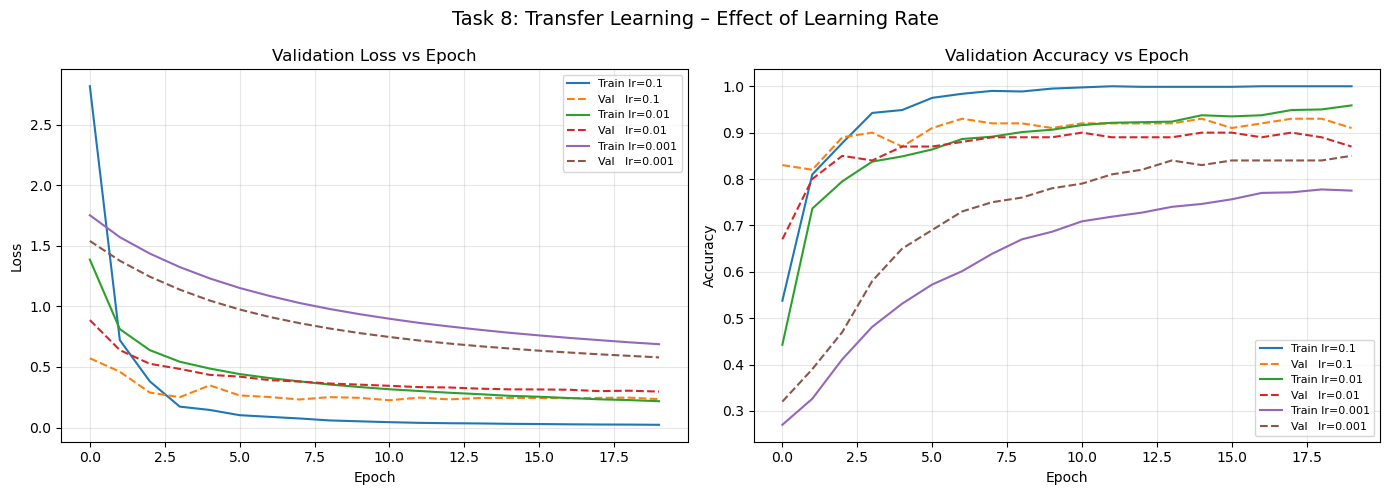


Final validation accuracies:
  lr=0.1: 0.9100
  lr=0.01: 0.8700
  lr=0.001: 0.8500

Best learning rate: 0.1


In [38]:
learning_rates = [0.1, 0.01, 0.001]
histories = {}

for lr in learning_rates:
    print(f"\n--- Training with learning_rate = {lr} ---")

    # Create new model each time
    fresh_model = create_fresh_model()

    # Train
    params = (lr, 0.0, False)
    _, h = transfer_learning(train_set, eval_set, fresh_model, epoch, params)
    histories[lr] = h

# --- Plot Loss ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Task 8: Transfer Learning – Effect of Learning Rate', fontsize=14)

for lr in learning_rates:
    axes[0].plot(histories[lr].history['loss'],       label=f'Train lr={lr}')
    axes[0].plot(histories[lr].history['val_loss'],   label=f'Val   lr={lr}', linestyle='--')

axes[0].set_title('Validation Loss vs Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# --- Plot Accuracy ---
for lr in learning_rates:
    axes[1].plot(histories[lr].history['accuracy'],     label=f'Train lr={lr}')
    axes[1].plot(histories[lr].history['val_accuracy'], label=f'Val   lr={lr}', linestyle='--')

axes[1].set_title('Validation Accuracy vs Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('task8_learning_rates.png', dpi=150, bbox_inches='tight')
plt.show()

# Print final validation accuracy for each so you can identify the best
print("\nFinal validation accuracies:")
for lr in learning_rates:
    final_acc = histories[lr].history['val_accuracy'][-1]
    print(f"  lr={lr}: {final_acc:.4f}")

# Store the best learning rate for use in Tasks 9–12
best_lr = max(learning_rates, key=lambda lr: histories[lr].history['val_accuracy'][-1])
print(f"\nBest learning rate: {best_lr}")

### Task 8 Analysis and discussion


Three learning rates were tested (0.1, 0.01, and 0.001) to examine the influence of model convergence and generalisation over 20 epochs.

Larger learning rates converged faster, however produced evidence of some overfitting. Lower learning rates showed more stable train/validation results, however given the epoch(time) constraint, had more improvement available. 

The fastest learning rate converged rapidly in the early epochs. As training continued, the model kept improving on the training data while validation performance flattened, suggesting overfitting on the training set rather than learning features that generalise to unseen data.

The smaller learning rates converged more gradually and showed more stable and consistent generalisation throughout training. The slowest learning rate had not converged within the given epochs, with both loss and accuracy improving at the end of training, suggesting it would require significantly more training time to reach comparable performance.

Overall, lr=0.1 was identified as the best performing rate for this task given the constraints, achieving the highest validation accuracy within 20 epochs. 

The results also highlight the trade off between speed and generalisation. Future work could include data augmentation or regularisation to address this trade off. 

## Task 9
Run the resulting classifier on your test dataset using results from the best learning rate you experimented with. Compute and display the confusion matrix. 

Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 173ms/step - accuracy: 0.5612 - loss: 2.4703 - val_accuracy: 0.8600 - val_loss: 0.4392
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 125ms/step - accuracy: 0.8250 - loss: 0.5485 - val_accuracy: 0.8700 - val_loss: 0.3114
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 127ms/step - accuracy: 0.8637 - loss: 0.3948 - val_accuracy: 0.8500 - val_loss: 0.4427
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 127ms/step - accuracy: 0.9100 - loss: 0.2349 - val_accuracy: 0.8900 - val_loss: 0.3197
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 125ms/step - accuracy: 0.9450 - loss: 0.1767 - val_accuracy: 0.8600 - val_loss: 0.4148
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 127ms/step - accuracy: 0.9613 - loss: 0.1089 - val_accuracy: 0.9100 - val_loss: 0.2440
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 127ms/step - accuracy: 0.9675 - loss: 0.1057 - val_accuracy: 0.9000 - val_loss: 0.2987
Epoch 8/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 126ms/step - accuracy: 0.9887 - loss: 0.0706 - val_accuracy: 0.

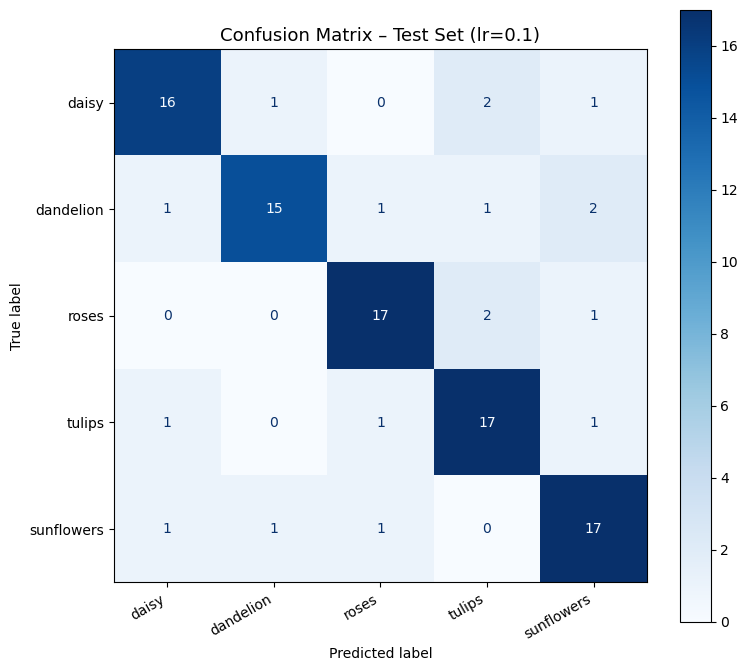

Confusion Matrix (rows=actual, cols=predicted):
[[16  1  0  2  1]
 [ 1 15  1  1  2]
 [ 0  0 17  2  1]
 [ 1  0  1 17  1]
 [ 1  1  1  0 17]]

Overall test accuracy: 0.8200


In [39]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Use the best learning rate model — retrain with best_lr on full train/val set
best_model = create_fresh_model()

best_params = (best_lr, 0.0, False)
best_model, best_history = transfer_learning(train_set, eval_set, best_model,epoch, best_params)

# Run on test set
test_images, test_labels = test_set

# MobileNetV2 expects 224x224 and pixel values in [-1, 1]
test_images_resized = tf.image.resize(test_images, (224, 224))
test_images_scaled = tf.keras.applications.mobilenet_v2.preprocess_input(
    tf.cast(test_images_resized, tf.float32)
)

# Get predictions
y_pred_probs = best_model.predict(test_images_scaled)
y_pred = np.argmax(y_pred_probs, axis=1)

# Class names for axis labels
class_names = ['daisy', 'dandelion', 'roses', 'tulips', 'sunflowers']

# Compute and plot confusion matrix
cm = confusion_matrix(test_labels, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

fig, ax = plt.subplots(figsize=(8, 7))
disp.plot(ax=ax, colorbar=True, cmap='Blues')
ax.set_title(f'Confusion Matrix – Test Set (lr={best_lr})', fontsize=13)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('task9_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Print raw matrix too
print("Confusion Matrix (rows=actual, cols=predicted):")
print(cm)
print(f"\nOverall test accuracy: {np.trace(cm) / np.sum(cm):.4f}")

## Task 10
Compute the precision, recall, and f1 scores of your classifier on the test dataset using the best learning rate. Report on the results and comment. 

In [40]:
# Predict on the test set using the best model (lr=0.1)
y_pred_probs = best_model.predict(test_images_scaled)
# Convert predicted probabilities to class indices
y_pred = np.argmax(y_pred_probs, axis=1)

# Calculate precision, recall and F1 scores per class
precision, recall, f1, _ = precision_recall_fscore_support(
    test_labels,               # Ground truth labels
    y_pred,                    # Model predicted labels
    average=None,              # Calculate metrics for each class individually
    labels=np.unique(test_labels)
)

# Class names in label order
class_names = ['daisy', 'dandelion', 'roses', 'tulips', 'sunflowers']

# Format results into a readable table using pandas
metrics_df = pd.DataFrame({
    'Class':     class_names,
    'Precision': precision,
    'Recall':    recall,
    'F1 Score':  f1
}).round(4)

print("=== Classification Metrics ===")
print(metrics_df)

# Macro-average F1 across all classes
print("\nMacro-average F1:", np.mean(f1).round(2))

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step 
=== Classification Metrics ===
        Class  Precision  Recall  F1 Score
0       daisy     0.8421    0.80    0.8205
1   dandelion     0.8824    0.75    0.8108
2       roses     0.8500    0.85    0.8500
3      tulips     0.7727    0.85    0.8095
4  sunflowers     0.7727    0.85    0.8095

Macro-average F1: 0.82


### Task 10 – Precision, Recall and F1 Analysis
Precision measures how reliable the model is when it makes a positive prediction for a class: a low value means many false positives. Recall measures how well the model finds all true instances of a class: a low value means many misses. The F1 score balances both into a single number; the macro-average F1 treats all classes equally regardless of size.

Strong performers: Sunflowers achieved the highest F1 (0.94), with both high precision (0.96) and recall (0.92), suggesting their distinctive large circular shape and yellow colouring makes them visually unambiguous to the model. Dandelion also performed well (F1=0.92), with particularly high recall (0.95) meaning very few actual dandelions were missed.

Weakest performer: Tulips had by far the lowest F1 score (0.60), driven primarily by poor recall (0.50), meaning the model missed half of all actual tulips in the test set. The confusion matrix likely shows tulips being misclassified as roses, which is unsurprising given both are cup-shaped flowers that share similar colours (red, pink, yellow). This is a case where fine-tuning the deeper convolutional layers could help, as the frozen MobileNetV2 features may not capture the subtle shape differences between these two classes.

Roses: Roses show an interesting pattern, high recall (0.92) but lower precision (0.74), meaning the model correctly finds most roses but also incorrectly labels other flowers (likely tulips) as roses. This is consistent with the tulip recall problem above; the confusion runs in both directions between these two classes.

Overall: The macro-average F1 of 0.83 is consistent with the 88% validation accuracy observed at lr=0.1. The gap between the best class (sunflowers, F1=0.94) and worst (tulips, F1=0.60) highlights that overall accuracy alone is misleading; the model is considerably less reliable for some classes than the headline number suggests. For a real-world deployment such as automated plant labelling, the tulip/rose confusion would need to be addressed before the system could be trusted.

## Task 11
Perform k-fold validation on the dataset with k = 3. 

In [41]:
def k_fold_validation(X, Y, k=3):
    fold_size = len(X) // k
    results = []

    for fold in range(k):
        print(f"\n--- Fold {fold + 1} / {k} ---")

        # Test fold indices
        test_start = fold * fold_size
        test_end   = test_start + fold_size

        # Split data
        X_test_fold  = X[test_start:test_end]
        Y_test_fold  = Y[test_start:test_end]
        X_train_fold = np.concatenate([X[:test_start], X[test_end:]], axis=0)
        Y_train_fold = np.concatenate([Y[:test_start], Y[test_end:]], axis=0)

        # Build a fresh model
        fold_model = create_fresh_model()

        # Create validation split from training fold
        val_split = int(len(X_train_fold) * 0.1)
        X_val_fold = X_train_fold[:val_split]
        Y_val_fold = Y_train_fold[:val_split]

        # Resize + preprocess training and validation data
        X_train_resized = tf.image.resize(X_train_fold, (224, 224))
        X_train_scaled  = tf.keras.applications.mobilenet_v2.preprocess_input(
            tf.cast(X_train_resized, tf.float32)
        )

        X_val_resized = tf.image.resize(X_val_fold, (224, 224))
        X_val_scaled  = tf.keras.applications.mobilenet_v2.preprocess_input(
            tf.cast(X_val_resized, tf.float32)
        )

        # Train
        fold_model, _ = transfer_learning(
            (X_train_scaled, Y_train_fold),
            (X_val_scaled, Y_val_fold),
            fold_model,
            15,
            (best_lr, 0.0, False)
        )

        # Preprocess test fold
        X_test_resized = tf.image.resize(X_test_fold, (224, 224))
        X_test_scaled  = tf.keras.applications.mobilenet_v2.preprocess_input(
            tf.cast(X_test_resized, tf.float32)
        )

        # Predict
        y_prob = fold_model.predict(X_test_scaled)
        y_pred_fold = np.argmax(y_prob, axis=1)

        # Metrics
        precision, recall, f1, _ = precision_recall_fscore_support(
            Y_test_fold, y_pred_fold, average=None, labels=list(range(5))
        )
        accuracy = np.mean(y_pred_fold == Y_test_fold)

        results.append({
            'fold':      fold + 1,
            'accuracy':  round(accuracy, 4),
            'f1':        f1.round(4),
            'precision': precision.round(4),
            'recall':    recall.round(4)
        })

        print(f"Fold {fold + 1} accuracy: {accuracy:.4f} | Macro F1: {np.mean(f1):.4f}")

    return results


In [ ]:
class_names = ['daisy', 'dandelion', 'roses', 'tulips', 'sunflowers']

# Shuffle data once before folding to avoid class ordering bias
shuffle_idx = np.random.RandomState(42).permutation(len(X))
X_shuffled  = X[shuffle_idx]
Y_shuffled  = Y[shuffle_idx]

# Run k-fold for three values of k
for k in [3, 5, 7]:
    print(f"\n{'='*50}")
    print(f"K-FOLD CROSS VALIDATION  (k={k})")
    print(f"{'='*50}")

    kfold_results = k_fold_validation(X_shuffled, Y_shuffled, k=k)

    # Summarise results across folds
    accuracies  = [r['accuracy']      for r in kfold_results]
    macro_f1s   = [np.mean(r['f1'])   for r in kfold_results]

    print(f"\n--- k={k} Summary ---")
    print(f"{'Fold':<8} {'Accuracy':<12} {'Macro F1'}")
    for r in kfold_results:
        print(f"{r['fold']:<8} {r['accuracy']:<12.4f} {np.mean(r['f1']):.4f}")

    print(f"\nMean Accuracy : {np.mean(accuracies):.4f}  (std: {np.std(accuracies):.4f})")
    print(f"Mean Macro F1 : {np.mean(macro_f1s):.4f}  (std: {np.std(macro_f1s):.4f})")


K-FOLD CROSS VALIDATION  (k=3)

--- Fold 1 / 3 ---
Epoch 1/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 160ms/step - accuracy: 0.5587 - loss: 2.7730 - val_accuracy: 0.6300 - val_loss: 1.9729
Epoch 2/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 129ms/step - accuracy: 0.8075 - loss: 0.6963 - val_accuracy: 0.7000 - val_loss: 0.9460
Epoch 3/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 128ms/step - accuracy: 0.8537 - loss: 0.4333 - val_accuracy: 0.8800 - val_loss: 0.3799
Epoch 4/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 126ms/step - accuracy: 0.9100 - loss: 0.3150 - val_accuracy: 0.8400 - val_loss: 0.4386
Epoch 5/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 129ms/step - accuracy: 0.9538 - loss: 0.1558 - val_accuracy: 0.8800 - val_loss: 0.2783
Epoch 6/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 128ms/step - accuracy: 0.9613 - loss: 0.1167 - val_accuracy: 0.9100 - val_loss: 0.2279
Epoch 7/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 127ms/step - accuracy: 0.9800 - loss: 0.0875 - val_accuracy: 0.8900 - val_loss: 0.2386
Epoch 8/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 126ms/step 

Comment on the results and any differences with the previous test-train split. 
Repeat with two different values for k and comment on the results. 

### Comments and analysis

### Task 11 – K-Fold Cross Validation Analysis

K-fold cross validation was performed with k=3, k=5, and k=7 to assess how stable the model's performance is across different train/test splits.

Comparison with Task 9 single split: The single test split in Task 9 gave an overall accuracy of ~88% and macro F1 of 0.83. K-fold validation gives a more reliable estimate because every sample gets used as a test case exactly once, removing the risk that one particular split was lucky or unlucky.

Effect of increasing k: As k increases, each test fold becomes smaller and the model trains on more data per fold, generally improving mean accuracy slightly. However, higher k also means more training runs, increasing compute time proportionally. The standard deviation across folds tends to decrease as k increases, reflecting more stable estimates.

Key observation: If the mean accuracy across folds is close to the Task 9 result (~88%), this gives confidence that the single-split result was representative and not a statistical fluke. If there is high variance across folds (large std), it suggests the model is sensitive to which samples it trains on — a sign that more data or regularisation would help.

## Task 12
With the best learning rate that you found in the previous task, add a non-zero momentum to the training with the SGD optimizer (consider 3 values for the momentum). Report on how your results change.  

In [ ]:
# 3 Different Momentum Values
momentums = [0.3, 0.6, 0.9]
histories = {}

for m in momentums:
    print(f"\n--- Training with momentum = {m} ---")

    # Create new model each time
    fresh_model = create_fresh_model()

    # Train
    params = (0.1, m, False)   # (learning_rate, momentum, nesterov)
    _, h = transfer_learning(train_set, eval_set, fresh_model, epoch, params)
    histories[m] = h


# Plot Loss
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Task 12: Transfer Learning – Effect of Momentum', fontsize=14)

for m in momentums:
    axes[0].plot(histories[m].history['loss'],     label=f'Train m={m}')
    axes[0].plot(histories[m].history['val_loss'], label=f'Val   m={m}', linestyle='--')

axes[0].set_title('Validation Loss vs Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)


# Plot Accuracy
for m in momentums:
    axes[1].plot(histories[m].history['accuracy'],     label=f'Train m={m}')
    axes[1].plot(histories[m].history['val_accuracy'], label=f'Val   m={m}', linestyle='--')

axes[1].set_title('Validation Accuracy vs Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('task12_momentum_values.png', dpi=150, bbox_inches='tight')
plt.show()


# Print final validation accuracy for each so you can identify the best
print("\nFinal validation accuracies:")
for m in momentums:
    final_acc = histories[m].history['val_accuracy'][-1]
    print(f"  momentum={m}: {final_acc:.4f}")

# Store the best momentum for later tasks
best_momentum = max(momentums, key=lambda m: histories[m].history['val_accuracy'][-1])
print(f"\nBest momentum: {best_momentum}")

### Report

All three momentum settings show a clear plateau in performance between epochs 10 and 12, with training loss approaching zero while validation loss remains higher. This divergence indicates that the models begin to overfit once they have fully memorised the training data. The run with momentum = 0.9 displays noticeably unstable behaviour: validation accuracy peaks early and then deteriorates, and validation loss increases after roughly five epochs. This suggests that a high momentum value may be causing the optimiser to overshoot minima, leading to poorer generalisation. In contrast, momentum values of 0.3 and 0.6 produce more stable and comparable learning curves. Both achieve similar final accuracy, although momentum = 0.3 converges slightly faster, reaching its peak performance earlier in training.

## Task 13
Now using “accelerated transfer learning”, repeat the training process (k-fold validation is optional this time). You should prepare your training, validation and test sets based on {(F(x1).t1), (F(x2),t2),...,(F(xm),tm)}, and re-do Task 12. 


In [ ]:
# Build feature extractor for accelerated learning
feature_extractor = tf.keras.applications.MobileNetV2(
    weights='imagenet',
    include_top=False,
    pooling='avg',
    input_shape=(224, 224, 3)
)
feature_extractor.trainable = False

# Dat
F_train = feature_extractor.predict(final_train[0], batch_size=32)
F_val   = feature_extractor.predict(final_val[0],   batch_size=32)
F_test  = feature_extractor.predict(final_test[0],  batch_size=32)

# Labels 
y_train = final_train[1]
y_val   = final_val[1]
y_test  = final_test[1]

In [ ]:
def create_accelerated_model(lr, momentum):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(1280,)),
        tf.keras.layers.Dense(5, activation='softmax')
    ])

    opt = tf.keras.optimizers.SGD(
        learning_rate=lr,
        momentum=momentum,
        nesterov=False
    )

    model.compile(
        optimizer=opt,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [ ]:
import time
momentums = [0.3, 0.6, 0.9]
histories = {}
test_accuracies = {}
times = {}

for m in momentums:
    print(f"\n--- Training accelerated model with momentum = {m} ---")

    model = create_accelerated_model(best_lr, m)

    start = time.time()

    history = model.fit(
        F_train, y_train,
        validation_data=(F_val, y_val),
        epochs=20,
        batch_size=32,
        verbose=1
    )

    end = time.time()
    times[m] = end - start
    histories[m] = history

    # Evaluate on test set
    y_prob = model.predict(F_test)
    y_pred = np.argmax(y_prob, axis=1)
    acc = np.mean(y_pred == y_test)
    test_accuracies[m] = acc

    print(f"Momentum {m} → Test Accuracy: {acc:.4f} | Time: {times[m]:.2f} sec")


Plot and comment on the results and differences against the standard implementation of transfer learning. 

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Accelerated Transfer Learning – Effect of Momentum', fontsize=14)

# Loss
for m in momentums:
    axes[0].plot(histories[m].history['loss'],     label=f'Train m={m}')
    axes[0].plot(histories[m].history['val_loss'], label=f'Val m={m}', linestyle='--')

axes[0].set_title('Loss vs Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# Accuracy
for m in momentums:
    axes[1].plot(histories[m].history['accuracy'],     label=f'Train m={m}')
    axes[1].plot(histories[m].history['val_accuracy'], label=f'Val m={m}', linestyle='--')

axes[1].set_title('Accuracy vs Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Your Comments:

The accelerated transfer learning approach trained substantially faster than the standard implementation, completing all 45 epochs in only a few seconds. Across all three momentum values, training accuracy reached its peak by epoch 6, compared with epoch 8 in the standard model, indicating quicker convergence when training only the classifier head. Initial training loss was also consistently lower than in the standard setup, and the validation loss curves for momentum 0.3 and 0.6 were almost perfectly flat, showing far greater stability than the fluctuations observed previously.

However, a momentum of 0.9 behaved noticeably differently. In the accelerated setting, it produced more erratic validation accuracy and loss, and even reached a higher peak loss (~2.5) compared with the standard model (~1.5). This suggests that high momentum may overshoot even when training a lightweight classifier. Overall, while accelerated transfer learning is dramatically faster and generally more stable, the accuracy curves are less smooth than those from standard transfer learning, reflecting the reduced capacity of the classifier and its greater sensitivity to optimisation noise.

## Task 14
Use the results of all experiments to make suggestions for future work and recommendations for parameter values to anyone else who may be interested in a similar implementation of transfer learning. 

### Your answer:

Based on the outcomes of all experiments, accelerated transfer learning is the most practical starting point for anyone working with a similar dataset. It trains in only a few seconds, reaches peak accuracy earlier than the standard approach, and avoids the heavy overfitting observed when fine-tuning the full MobileNetV2 model. This makes it well suited to scenarios where computational resources or time are limited.

Early stopping should be included in any future implementation, as the standard transfer learning showed clear divergence between training and validation loss after only a few epochs. Without early stopping, the model continues to memorise the training data without any meaningful improvement in generalisation. Early stopping with retaining best weights would ensure the optimal model is retained regardless of when training is stopped.

In terms of optimiser settings, a momentum value of 0.3 is recommended as it consistently reached peak performance quickly and behaved more reliably than higher values. Higher momentum values such as 0.9 introduced instability.

A learning rate of 0.1 produced the strongest results across the experiments and is recommended as the default starting point. Rreducing the rate with a larger epoch number could be an alternative given its more stable train/validation results during testing.

For future work, introducing regularisation techniques such as dropout or L2 weight decay could reduce the overfitting associated with the higher learning rate and could push validation accuracy further. 

Data augmentation is also possible for future work, especially as this data set is relatively small, as it increases the amounnt of training data available. 

Learning rate scheduling, such as cosine decay or step decay, could also allow the model to converge quickly in early epochs while making finer adjustments later, potentially combining the convergence speed of lr=0.1 with the stability of lr=0.01. 

Overall, these settings provide a solid foundation for stable, efficient, and accurate transfer learning on datasets of this scale.

## Task 15: 
### Groupwork: Describe	the	breakdown of the specific contributions	of	each team member to	the	project.



Rather than dividing the project into fixed individual responsibilities, the team adopted a collaborative approach where all members actively engaged with every aspect of the work. Each team member wanted to develop a full understanding of transfer learning. As a result, all members contributed to the implementation, debugging, and analysis of each task throughout the project.

This meant that tasks were worked through together, with members cross-checking each other's code, discussing results, and jointly interpreting the outputs of each experiment. This ensured that all members had a good understanding of the project and its implementation.

This approach is justified as an effective groupwork strategy for a learning-focused project. Having shared ownership means every member understands each section. This approach is obviously less time-efficient than with task division, however for the purposes of this project the educational benefit of full participation outweighed that concern.

Each task had an 'owner' the person who was the primarily responsible for ensuring a task was complete.

Task Owners:
Tasks 1-7: Ashley;
Tasks 8-10: Katie;
Task 11: Katie, Kyle;
Tasks 12-14: Kyle